In [60]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os

In [61]:
load_dotenv(override=True)

True

In [51]:
# model = ChatOpenAI()

In [62]:
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

In [53]:
# create a state

class LLMState(TypedDict):
    question: str
    answer: str

In [54]:
def llm_qa(state: LLMState) -> LLMState:

    #extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # ask that question to the LLM
    state['answer'] = answer

    return state

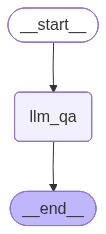

In [55]:
# create our graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

graph.compile()

In [56]:
workflow = graph.compile()

In [57]:
output_state = workflow.invoke({"question": "Who is Elon Musk"})
print(output_state['answer'])

**Elon Musk: A Visionary Entrepreneur and Innovator**

Elon Musk is a South African-born entrepreneur, inventor, and business magnate who has revolutionized multiple industries through his innovative ventures and ideas. He is best known for his ambitious goals and vision for a sustainable future, which has made him a household name and a leading figure in the tech and business world.

**Early Life and Education**

Born on June 28, 1971, in Pretoria, South Africa, Musk grew up with a passion for reading and learning. He taught himself computer programming and, at the age of 12, created his first software program, a space-themed video game called Blastar. Musk moved to Canada in 1992 to attend college and later transferred to the University of Pennsylvania, where he graduated with a degree in economics and physics.

**Career**

Musk's career is marked by a series of successful ventures:

1. **Zip2** (1995): Musk co-founded Zip2, a software company that provided online content publishing 

In [59]:
model.invoke('How far is moon from the earth?').content

"The average distance from the Earth to the Moon is approximately 384,400 kilometers (238,900 miles). This distance is constantly changing due to the elliptical shape of the Moon's orbit around the Earth. At its closest point (called perigee), the distance is about 356,400 kilometers (221,500 miles), and at its farthest point (apogee), the distance is about 405,500 kilometers (252,000 miles)."

In [58]:
import os
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

print(llm.invoke("What is LangGraph?").content)

LangGraph is an open-source, large language model developed by the LangGraph team. It's designed to process and understand human language, similar to other popular models like LLaMA or BERT. The model's primary function is to generate text based on the input it receives, making it useful for a variety of applications such as chatbots, language translation, and content creation.

As LangGraph is open-source, the model and its training data are freely available for anyone to use, modify, and distribute. This allows developers and researchers to build upon and improve the model, potentially leading to advancements in natural language processing (NLP) and other related fields.

Some key features of LangGraph include:

1. **Text generation**: LangGraph can create coherent and context-specific text based on a given prompt or input.
2. **Language understanding**: The model is trained on a vast amount of text data, allowing it to comprehend and interpret human language.
3. **Customizability**:

# Prompt Chaining

Start -> Generate Outline -> Generate Blog -> End

Start -> Topic-Generate text -> LLM Summarizer -> End

In [88]:
class SummarizerState(TypedDict):
    topic: str
    text: str
    summarization_percentage: float
    summary: str

In [89]:
graph = StateGraph(SummarizerState)

In [90]:
def generate_text(state:SummarizerState) -> SummarizerState:
    topic = state['topic']

    prompt = f'Create the text on the given topic {topic}'
    text = model.invoke(prompt)
    state['text'] = text.content
    return state
    


In [91]:
def generate_summary(state:SummarizerState) -> SummarizerState:
    topic = state['topic']
    text = state['text']
    summarization_percentage = state['summarization_percentage']

    prompt = f'Generate the summary based on the given topic {topic} and {text} and the summary should be {summarization_percentage} of the text'
    summary = model.invoke(prompt)
    state['summary'] = summary.content
    return state

In [92]:
graph.add_node('generate_text', generate_text)
graph.add_node('generate_summary', generate_summary)

In [93]:
graph.add_edge(START, 'generate_text')
graph.add_edge('generate_text', 'generate_summary')
graph.add_edge('generate_summary', END)

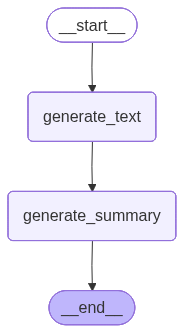

In [94]:
graph.compile()

In [95]:
workflow = graph.compile()

In [100]:
final_state = workflow.invoke({'topic':'Calisthenics vs Gym', 'summarization_percentage': 0.5})

In [102]:
print(final_state['text'])

**Calisthenics vs Gym: Which is the Better Option for You?**

When it comes to staying physically fit, there are numerous options available, and two of the most popular ones are calisthenics and gym workouts. While both methods have their own set of benefits and drawbacks, they cater to different needs and preferences. In this article, we will delve into the world of calisthenics and gym workouts, comparing their advantages and disadvantages to help you decide which one is the better option for you.

**What is Calisthenics?**

Calisthenics is a form of exercise that uses body weight as resistance to build strength, flexibility, and endurance. It involves various movements such as push-ups, squats, lunges, planks, and other exercises that work multiple muscle groups at once. Calisthenics is often performed outdoors or in a minimalist setting, without the need for any specialized equipment.

**What is a Gym Workout?**

A gym workout, on the other hand, typically involves using various ma

In [103]:
print(final_state['summary'])

**Calisthenics vs Gym: Which is the Better Option for You**

When it comes to physical fitness, two popular options are calisthenics and gym workouts. Calisthenics uses body weight as resistance to build strength, flexibility, and endurance, and can be performed outdoors or in a minimalist setting. On the other hand, gym workouts involve using various machines and equipment to target specific muscle groups, often requiring a membership and being more expensive.

**Key Advantages and Disadvantages**

Calisthenics offers advantages such as being cost-effective, convenient, and building functional strength, while its disadvantages include limited progression and lack of variety. Gym workouts offer variety, progressive overload, social benefits, and specialized equipment, but are expensive, time-consuming, and can be intimidating.

**Choosing the Better Option**

The choice between calisthenics and gym workouts depends on personal preferences, goals, and lifestyle. Calisthenics is ideal fo